In [1]:
import requests
import pandas as pd

url = "https://banks.data.fdic.gov/api/financials"
params = {
    "filters": "REPDTE:20231231",
    "fields": "NAME,CERT,ASSET,DEP,EQ,LIAB",
    "limit": 30,
    "sort_by": "ASSET",
    "sort_order": "DESC",
    "format": "json"
}

response = requests.get(url, params=params)
data = response.json()

banks = pd.DataFrame([d["data"] for d in data["data"]])
banks.to_csv("banks_raw.csv", index=False)
print(banks)

         ASSET   CERT         EQ        LIAB         DEP  \
0   3395126000    628  299279000  3095803000  2498231000   
1   2540116000   3510  236206000  2303910000  2031779000   
2   1733244000   3511  162969000  1570242000  1416886000   
3   1684710000   7213  162945000  1520999000  1327597000   
4    650658504   6548   61526628   588497319   524697711   
5    557463343   6384   50108085   507345324   428985450   
6    527548000   9846   57994000   469404000   407533000   
7    521102000  33124   54783000   466282000   381773000   
8    475628639   4297   53187218   422441214   374160480   
9    367174651  18409   46280437   320894214   303720159   
10   332529000    639   27626000   304903000   287126000   
11   304549000  57450   16079000   288470000   257579000   
12   293238000     14   25391000   267847000   227068000   
13   265689963  16571   32976006   232692559   206601880   
14   221750244  57957   23288619   198461625   180831726   
15   213768000   6672   21191000   19257

In [2]:
import numpy as np

def maximum_entropy_matrix(interbank_assets, interbank_liabilities):
    """
    Reconstructs a plausible interbank exposure matrix X
    where X[i,j] = exposure of bank i to bank j,
    given each bank's total interbank assets (row sums)
    and total interbank liabilities (column sums).
    """
    n = len(interbank_assets)
    a = np.array(interbank_assets, dtype=float)
    l = np.array(interbank_liabilities, dtype=float)
    total = a.sum()

    # Initial guess: outer product / total
    X = np.outer(a, l) / total
    np.fill_diagonal(X, 0)  # no self-lending

    # Iterative proportional fitting (RAS algorithm)
    for _ in range(1000):
        row_sums = X.sum(axis=1)
        X = X * (a / (row_sums + 1e-10))[:, None]
        np.fill_diagonal(X, 0)

        col_sums = X.sum(axis=0)
        X = X * (l / (col_sums + 1e-10))[None, :]
        np.fill_diagonal(X, 0)

    return X

In [3]:

import pandas as pd

banks = pd.read_csv("banks_raw.csv")  # your data above, saved as CSV

# --- Estimate interbank assets/liabilities as a % of total assets ---
# Real-world calibration: interbank exposure is typically 10-20% of total assets
# (BIS/ECB studies). We use 15% as a documented, defensible assumption.
INTERBANK_RATIO = 0.15

banks["interbank_assets"] = banks["ASSET"] * INTERBANK_RATIO
banks["interbank_liabilities"] = banks["LIAB"] * INTERBANK_RATIO

# --- Maximum Entropy reconstruction of the exposure matrix ---
def maximum_entropy_matrix(interbank_assets, interbank_liabilities, iters=1000):
    n = len(interbank_assets)
    a = np.array(interbank_assets, dtype=float)
    l = np.array(interbank_liabilities, dtype=float)
    total = a.sum()

    X = np.outer(a, l) / total
    np.fill_diagonal(X, 0)

    for _ in range(iters):
        row_sums = X.sum(axis=1)
        X = X * (a / (row_sums + 1e-10))[:, None]
        np.fill_diagonal(X, 0)

        col_sums = X.sum(axis=0)
        X = X * (l / (col_sums + 1e-10))[None, :]
        np.fill_diagonal(X, 0)

    return X

exposure_matrix = maximum_entropy_matrix(
    banks["interbank_assets"].values,
    banks["interbank_liabilities"].values
)

# exposure_matrix[i,j] = how much bank i is exposed to (has lent to) bank j
np.save("exposure_matrix.npy", exposure_matrix)
print("Exposure matrix shape:", exposure_matrix.shape)
print(pd.DataFrame(exposure_matrix, index=banks["NAME"], columns=banks["NAME"]).round(0))

Exposure matrix shape: (30, 30)
NAME                          JPMORGAN CHASE BANK NA  BANK OF AMERICA NA  \
NAME                                                                       
JPMORGAN CHASE BANK NA                           0.0          99343267.0   
BANK OF AMERICA NA                        99733066.0                 0.0   
WELLS FARGO BANK NA                       63545095.0          42912631.0   
CITIBANK NATIONAL ASSN                    61516427.0          41542652.0   
U S BANK NATIONAL ASSN                    22178532.0          14977382.0   
PNC BANK NATIONAL ASSN                    18900512.0          12763703.0   
TRUIST BANK                               17842539.0          12049243.0   
GOLDMAN SACHS BANK USA                    17620871.0          11899549.0   
CAPITAL ONE NATIONAL ASSN                 16037870.0          10830532.0   
TD BANK NATIONAL ASSN                     12301234.0           8307145.0   
BANK OF NEW YORK MELLON                   11129126.0    

In [4]:
def debtrank(exposure_matrix, equity, shocked_bank_idx, shock_fraction=0.5):
    """
    exposure_matrix[i,j] = exposure of bank i to bank j
    equity = array of each bank's equity
    shocked_bank_idx = index of the bank that gets hit
    shock_fraction = how much of that bank's equity is wiped out (e.g. 0.5 = 50%)
    """
    n = len(equity)

    # Impact matrix: how much bank i's equity is hit if bank j defaults
    W = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if equity[i] > 0:
                W[i, j] = min(1, exposure_matrix[i, j] / equity[i])

    # State: 0 = undistressed, (0,1) = distressed, 1 = defaulted
    h = np.zeros(n)  # distress level
    state = np.array(["U"] * n)  # U=undistressed, D=distressed, I=inactive(already fully accounted)

    h[shocked_bank_idx] = shock_fraction
    state[shocked_bank_idx] = "D"

    while "D" in state:
        distressed = np.where(state == "D")[0]
        h_new = h.copy()

        for i in range(n):
            if state[i] != "I":
                impact = sum(W[i, j] * h[j] for j in distressed)
                h_new[i] = min(1, h[i] + impact)

        for j in distressed:
            state[j] = "I"  # move distressed banks to inactive after propagating

        for i in range(n):
            if state[i] == "U" and h_new[i] > 0:
                state[i] = "D"

        h = h_new

    # DebtRank = total economic value lost / total initial economic value
    debtrank_score = sum(h[i] * equity[i] for i in range(n) if i != shocked_bank_idx) / equity.sum()
    return h, debtrank_score

# --- Run it: shock the largest bank (JPMorgan, index 0) ---
equity = banks["EQ"].values
h_final, dr_score = debtrank(exposure_matrix, equity, shocked_bank_idx=0, shock_fraction=0.5)

results = pd.DataFrame({
    "Bank": banks["NAME"],
    "Final Distress Level": h_final
}).sort_values("Final Distress Level", ascending=False)

print(f"\nDebtRank Systemic Impact Score: {dr_score:.4f}")
print(results.head(10))


DebtRank Systemic Impact Score: 0.3094
                            Bank  Final Distress Level
11       CHARLES SCHWAB BANK SSB              0.679111
0         JPMORGAN CHASE BANK NA              0.500000
21                     ALLY BANK              0.489816
26             NORTHERN TRUST CO              0.467225
19  MORGAN STANLEY PRIVATE BK NA              0.463555
22         KEYBANK NATIONAL ASSN              0.453248
29   FLAGSTAR BANK NATIONAL ASSN              0.448381
27                 DISCOVER BANK              0.436769
28                  UBS BANK USA              0.436165
10       BANK OF NEW YORK MELLON              0.435019


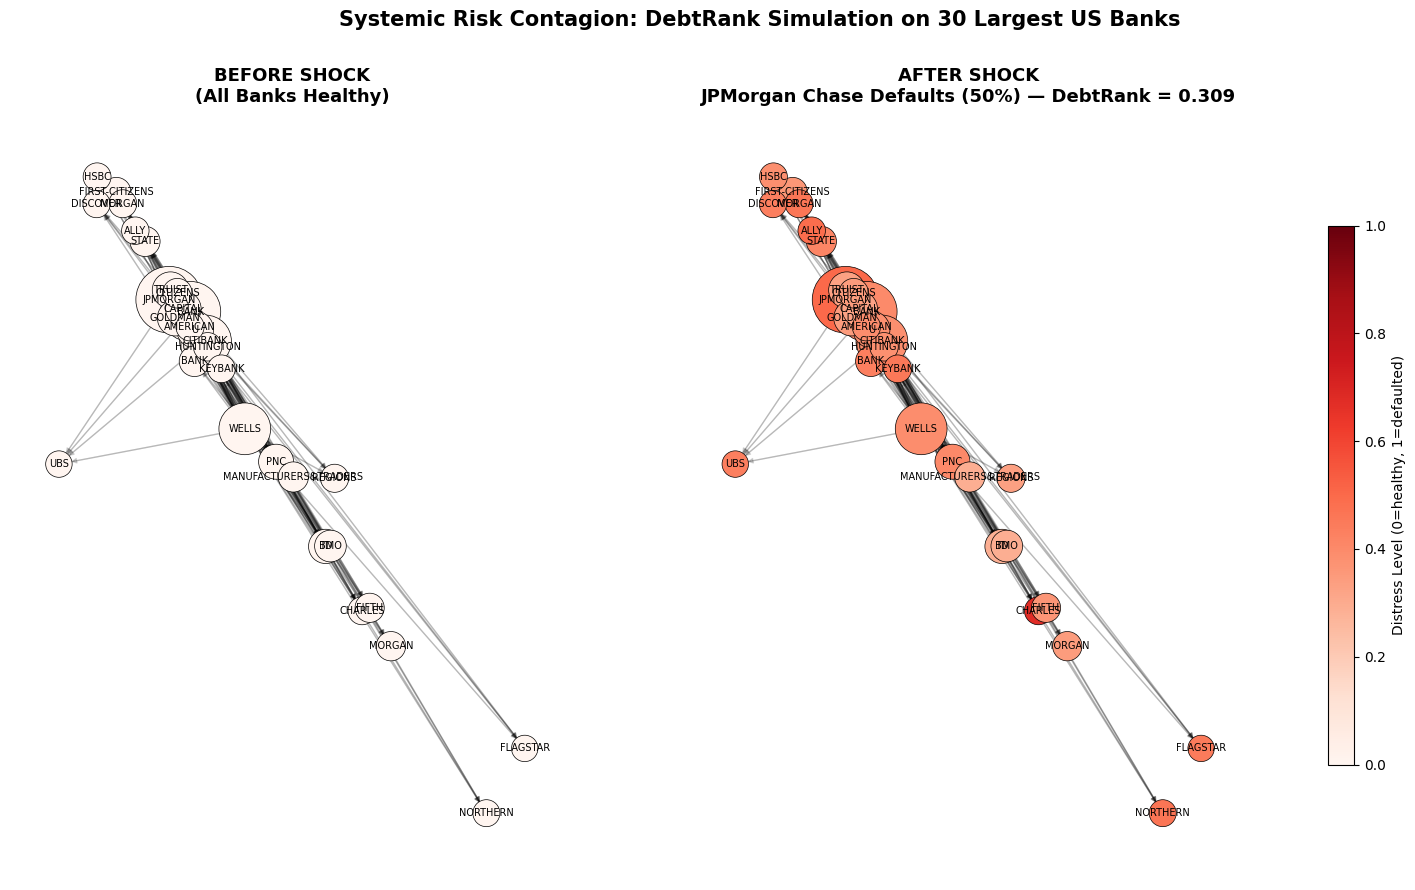

In [5]:
import networkx as nx
import matplotlib.pyplot as plt


banks = pd.read_csv("banks_raw.csv")
exposure_matrix = np.load("exposure_matrix.npy")
names = banks["NAME"].values
equity = banks["EQ"].values

# Build directed graph
G = nx.DiGraph()
for i, name in enumerate(names):
    G.add_node(i, name=name, equity=equity[i])

# Only add edges above a threshold so the graph isn't visually cluttered
threshold = np.percentile(exposure_matrix[exposure_matrix > 0], 70)
for i in range(len(names)):
    for j in range(len(names)):
        if exposure_matrix[i, j] > threshold:
            G.add_edge(i, j, weight=exposure_matrix[i, j])

pos = nx.spring_layout(G, seed=42, k=0.8)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for ax, (h_vals, title) in zip(
    axes,
    [(np.zeros(len(names)), "BEFORE SHOCK\n(All Banks Healthy)"),
     (h_final, f"AFTER SHOCK\nJPMorgan Chase Defaults (50%) — DebtRank = {dr_score:.3f}")]
):
    node_colors = h_vals
    node_sizes = [300 + (equity[i] / equity.max()) * 2000 for i in G.nodes()]

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15, arrows=True, arrowsize=8)
    nodes = nx.draw_networkx_nodes(
        G, pos, ax=ax, node_size=node_sizes,
        node_color=node_colors, cmap=plt.cm.Reds,
        vmin=0, vmax=1, edgecolors="black", linewidths=0.5
    )
    labels = {i: names[i].split(" ")[0] for i in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=7)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.axis("off")

plt.colorbar(nodes, ax=axes, label="Distress Level (0=healthy, 1=defaulted)", shrink=0.7)
plt.suptitle("Systemic Risk Contagion: DebtRank Simulation on 30 Largest US Banks",
             fontsize=15, fontweight="bold")
plt.savefig("debtrank_network.png", dpi=200, bbox_inches="tight")
plt.show()

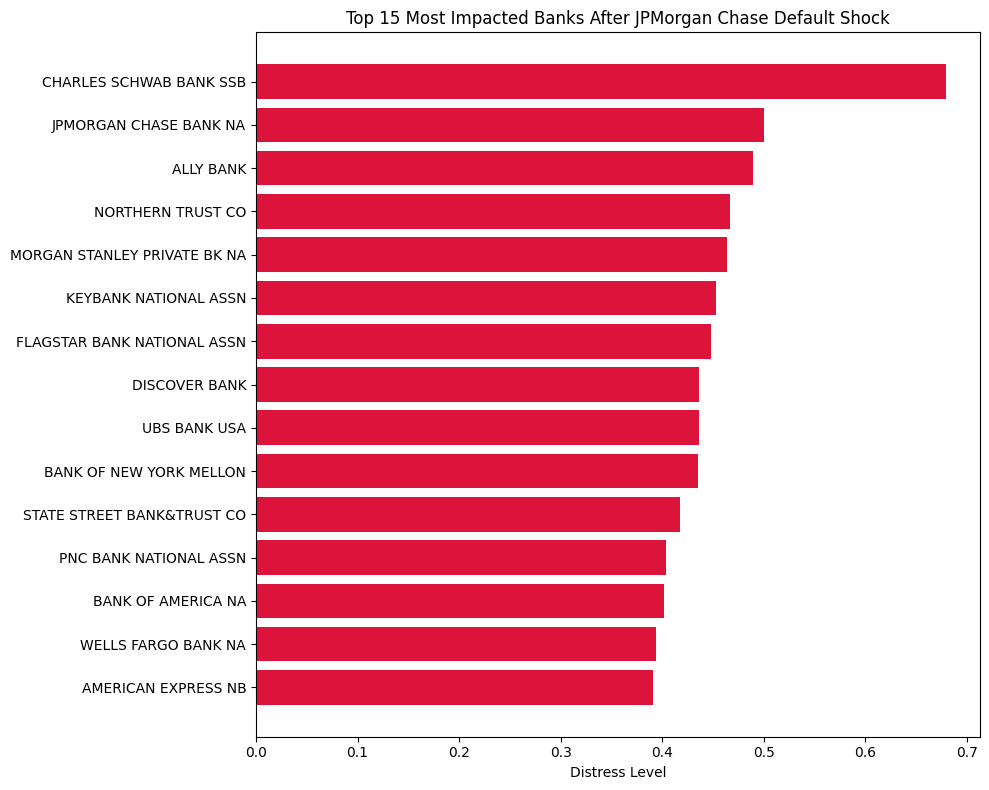

In [6]:
plt.figure(figsize=(10, 8))
results_sorted = results.head(15)
plt.barh(results_sorted["Bank"], results_sorted["Final Distress Level"], color="crimson")
plt.xlabel("Distress Level")
plt.title("Top 15 Most Impacted Banks After JPMorgan Chase Default Shock")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("distress_ranking.png", dpi=200)
plt.show()

In [7]:
# Reduce label clutter - only label banks above a size threshold
labels = {i: names[i].split(" ")[0] for i in G.nodes() if equity[i] > np.percentile(equity, 50)}
nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=7)

{0: Text(-0.2189026385550924, 0.09844835562533102, 'JPMORGAN'),
 1: Text(-0.14540870111927207, 0.08664901190268992, 'BANK'),
 2: Text(0.04034170027208253, -0.029420993560857086, 'WELLS'),
 3: Text(-0.0944032563082593, 0.05753208193876681, 'CITIBANK'),
 4: Text(-0.13023620658923882, 0.06891603504773154, 'U'),
 5: Text(0.14757467362601656, -0.061996573331675395, 'PNC'),
 6: Text(-0.2144333381187881, 0.10794680321294492, 'TRUIST'),
 7: Text(-0.19792820149101437, 0.08029613962798837, 'GOLDMAN'),
 8: Text(-0.17030070137471232, 0.0893432056794737, 'CAPITAL'),
 9: Text(0.31758326588773705, -0.14586478856167376, 'TD'),
 10: Text(-0.13211241396593973, 0.03747298069198818, 'BANK'),
 12: Text(-0.3016728253642236, 0.15613971419740624, 'STATE'),
 13: Text(0.33394632593986423, -0.14549602165446693, 'BMO'),
 14: Text(-0.19090914980586837, 0.10484437205140311, 'CITIZENS'),
 18: Text(0.20676339536876992, -0.07710558521828467, 'MANUFACTURERS&TRADERS')}

                        Bank  Total Assets  Systemic Impact (DebtRank)
0     JPMORGAN CHASE BANK NA    3395126000                    0.309404
1         BANK OF AMERICA NA    2540116000                    0.244909
2        WELLS FARGO BANK NA    1733244000                    0.174338
3     CITIBANK NATIONAL ASSN    1684710000                    0.169600
4     U S BANK NATIONAL ASSN     650658504                    0.068536
5     PNC BANK NATIONAL ASSN     557463343                    0.059239
6                TRUIST BANK     527548000                    0.055078
7     GOLDMAN SACHS BANK USA     521102000                    0.054683
8  CAPITAL ONE NATIONAL ASSN     475628639                    0.049666
9      TD BANK NATIONAL ASSN     367174651                    0.037908


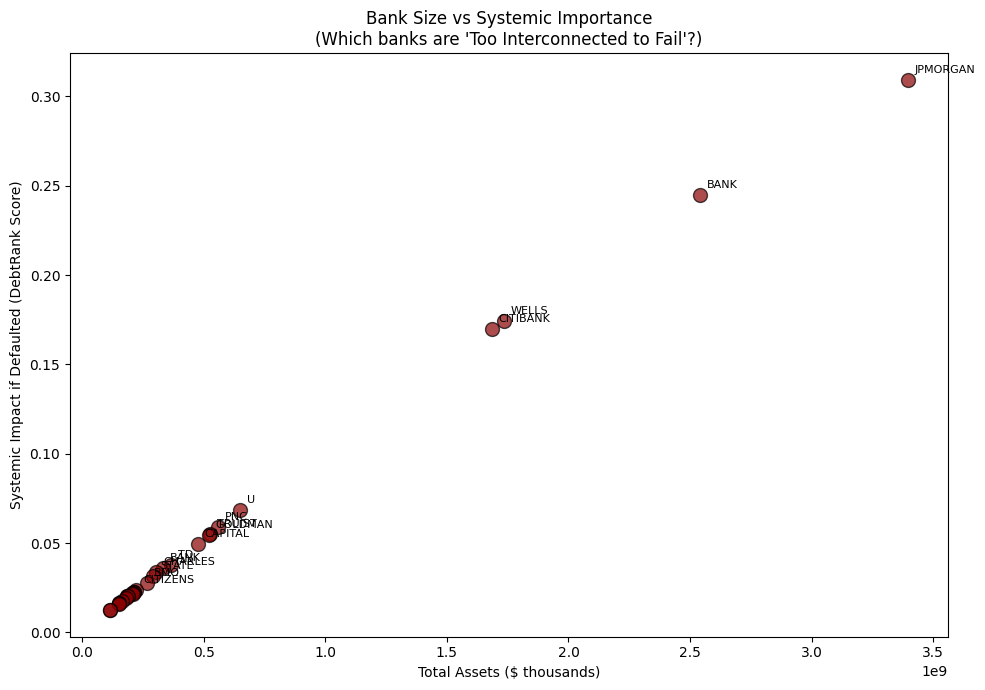

In [8]:
systemic_impact = []
for idx in range(len(names)):
    _, dr = debtrank(exposure_matrix, equity, shocked_bank_idx=idx, shock_fraction=0.5)
    systemic_impact.append(dr)

sensitivity_df = pd.DataFrame({
    "Bank": names,
    "Total Assets": banks["ASSET"].values,
    "Systemic Impact (DebtRank)": systemic_impact
}).sort_values("Systemic Impact (DebtRank)", ascending=False)

print(sensitivity_df.head(10))

# Plot: Bank size vs systemic importance
plt.figure(figsize=(10, 7))
plt.scatter(sensitivity_df["Total Assets"], sensitivity_df["Systemic Impact (DebtRank)"],
            s=100, alpha=0.7, color="darkred", edgecolors="black")
for i, row in sensitivity_df.iterrows():
    if row["Systemic Impact (DebtRank)"] > sensitivity_df["Systemic Impact (DebtRank)"].median():
        plt.annotate(row["Bank"].split(" ")[0], (row["Total Assets"], row["Systemic Impact (DebtRank)"]),
                     fontsize=8, xytext=(5,5), textcoords="offset points")
plt.xlabel("Total Assets ($ thousands)")
plt.ylabel("Systemic Impact if Defaulted (DebtRank Score)")
plt.title("Bank Size vs Systemic Importance\n(Which banks are 'Too Interconnected to Fail'?)")
plt.tight_layout()
plt.savefig("sensitivity_analysis.png", dpi=200)
plt.show()